# 📊 Module 9 — Model Evaluation & Performance Analysis

**Project:** Speech Emotion Recognition System  
**Dataset:** RAVDESS — 1,440 clips, 264 features, 8 emotion classes  
**Goal:** Deeply evaluate and compare all trained models (LR, RF, SVM, ANN, CNN) using
comprehensive metrics, visualisations, and error analysis.

---
### What This Module Covers
```
9.1  Imports & Configuration
9.2  Load All Models + Test Data
9.3  Generate Predictions (All 5 Models)
9.4  Accuracy, Precision, Recall, F1-Score
9.5  Confusion Matrices — Grid View
9.6  Classification Reports
9.7  Per-Class F1 Heatmap
9.8  ROC / AUC Curves (One-vs-Rest)
9.9  Error Analysis — Misclassified Samples
9.10 ML vs Deep Learning Comparison Dashboard
9.11 Module 9 Summary
```

## 9.1 — Imports & Configuration

In [1]:
import os, json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
from tensorflow import keras

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler, LabelEncoder, label_binarize
from sklearn.metrics         import (accuracy_score, precision_score, recall_score,
                                      f1_score, confusion_matrix,
                                      classification_report, roc_curve, auc)

import sys
sys.path.insert(0, '..')
from src.feature_extraction import extract_mfcc_2d

# ── Colour Theme ─────────────────────────────────────────────────────────────
DARK  = '#0d0d1a'
PANEL = '#12122a'
CARD  = '#1a1a35'
TEXT  = '#e2e8f0'
ACC   = '#818cf8'

plt.rcParams.update({
    'figure.facecolor': DARK,  'axes.facecolor':  PANEL,
    'axes.labelcolor':  TEXT,  'text.color':       TEXT,
    'xtick.color': '#9090b0',  'ytick.color':  '#9090b0',
    'grid.color':  '#252545',  'font.size':         10,
    'axes.spines.top':  False, 'axes.spines.right': False,
})
sns.set_style('darkgrid')

ECOLORS = {
    'neutral':'#94a3b8','calm':'#22d3ee','happy':'#fbbf24','sad':'#60a5fa',
    'angry':'#f87171','fearful':'#c084fc','disgust':'#4ade80','surprised':'#fb923c'
}
MODEL_COLORS = {
    'Logistic Regression': '#a78bfa',
    'Random Forest'      : '#34d399',
    'SVM'                : '#fbbf24',
    'ANN'                : '#818cf8',
    'CNN'                : '#f87171',
}

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE      = os.path.dirname(os.path.abspath('__file__'))
DATA_PROC = os.path.join(BASE, '..', 'Data', 'processed')
MODEL_DIR = os.path.join(BASE, '..', 'models')
REP_DIR   = os.path.join(BASE, '..', 'reports', 'evaluation')
os.makedirs(REP_DIR, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE    = 0.20
VAL_SIZE     = 0.10

print('✅ All imports successful!')
print(f'   TensorFlow : {tf.__version__}')
print(f'   Output dir : {REP_DIR}')

✅ All imports successful!
   TensorFlow : 2.21.0
   Output dir : C:\Speech Emotion Recognition\notebooks\..\reports\evaluation


## 9.2 — Load All Models & Test Data

In [2]:
# ── Load numpy arrays ─────────────────────────────────────────────────────────
X_feat  = np.load(os.path.join(DATA_PROC, 'X_features.npy'))   # (1440, 264)
X_audio = np.load(os.path.join(DATA_PROC, 'X_audio.npy'))       # (1440, 66150)
y_raw   = np.load(os.path.join(DATA_PROC, 'y_labels.npy'))      # (1440,)

with open(os.path.join(DATA_PROC, 'preprocessing_config.json')) as f:
    cfg = json.load(f)
EMOTIONS  = cfg['emotion_classes']
N_CLASSES = len(EMOTIONS)
SR        = cfg['target_sr']

# ── Same splits as training (identical random seed) ──────────────────────────
X_tr0, X_test, y_tr0, y_test = train_test_split(
    X_feat, y_raw, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_raw)
X_train, X_val, y_train, y_val = train_test_split(
    X_tr0, y_tr0,
    test_size    = VAL_SIZE / (1 - TEST_SIZE),
    random_state = RANDOM_STATE, stratify=y_tr0)

# ── Flat feature scaler (ML + ANN) ───────────────────────────────────────────
scaler     = joblib.load(os.path.join(MODEL_DIR, 'scaler.pkl'))
X_test_sc  = scaler.transform(X_test)

# ── 2-D MFCC maps for CNN ─────────────────────────────────────────────────────
N_MFCC = 40;  MAX_FRAMES = 130
X_cnn_tr0, X_cnn_test, _, _ = train_test_split(
    np.zeros((len(X_feat), 1)), y_raw,
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_raw)
cnn_test_idx = np.where(
    np.isin(np.arange(len(X_feat)),
            np.where(train_test_split(
                np.arange(len(X_feat)), y_raw,
                test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_raw
            )[1] >= 0)[0])
)[0]

# Rebuild CNN test set using same split
_, X_audio_test, _, _ = train_test_split(
    X_audio, y_raw, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_raw)

print('🔄 Building CNN test MFCC maps...')
X_cnn_test = np.stack([
    extract_mfcc_2d(sig, sr=SR, n_mfcc=N_MFCC, max_frames=MAX_FRAMES)
    for sig in X_audio_test
])
mean_ = X_cnn_test.mean(axis=(1,2), keepdims=True)
std_  = X_cnn_test.std(axis=(1,2),  keepdims=True) + 1e-8
X_cnn_test = (X_cnn_test - mean_) / std_
X_cnn_test = X_cnn_test[..., np.newaxis].astype(np.float32)

# ── Load ML models ────────────────────────────────────────────────────────────
lr_model  = joblib.load(os.path.join(MODEL_DIR, 'logistic_regression.pkl'))
rf_model  = joblib.load(os.path.join(MODEL_DIR, 'random_forest.pkl'))
svm_model = joblib.load(os.path.join(MODEL_DIR, 'svm_model.pkl'))

# ── Load DL models ────────────────────────────────────────────────────────────
ann_model = keras.models.load_model(os.path.join(MODEL_DIR, 'ann_best.keras'))
cnn_model = keras.models.load_model(os.path.join(MODEL_DIR, 'cnn_best.keras'))

print(f'\n✅ All 5 models loaded!')
print(f'   Test set size : {len(y_test)} samples')
print(f'   Emotions      : {EMOTIONS}')
print(f'   CNN test shape: {X_cnn_test.shape}')

🔄 Building CNN test MFCC maps...



✅ All 5 models loaded!
   Test set size : 288 samples
   Emotions      : ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']
   CNN test shape: (288, 40, 130, 1)


## 9.3 — Generate Predictions (All 5 Models)

In [3]:
# ── Predictions & probability estimates ───────────────────────────────────────
preds = {}
proba = {}

# ML models
for name, mdl in [('Logistic Regression', lr_model),
                   ('Random Forest',       rf_model),
                   ('SVM',                 svm_model)]:
    preds[name] = mdl.predict(X_test_sc)
    if hasattr(mdl, 'predict_proba'):
        proba[name] = mdl.predict_proba(X_test_sc)
    elif hasattr(mdl, 'decision_function'):
        df = mdl.decision_function(X_test_sc)
        # Softmax transform
        e  = np.exp(df - df.max(axis=1, keepdims=True))
        proba[name] = e / e.sum(axis=1, keepdims=True)
    print(f'✅ {name:25s} → predictions done')

# DL models
ann_prob = ann_model.predict(X_test_sc,   verbose=0)
cnn_prob = cnn_model.predict(X_cnn_test,  verbose=0)
preds['ANN'] = np.argmax(ann_prob, axis=1)
preds['CNN'] = np.argmax(cnn_prob, axis=1)
proba['ANN'] = ann_prob
proba['CNN'] = cnn_prob
print(f'✅ {"ANN":25s} → predictions done')
print(f'✅ {"CNN":25s} → predictions done')

MODEL_NAMES = ['Logistic Regression', 'Random Forest', 'SVM', 'ANN', 'CNN']
print(f'\n✅ All predictions ready. Test ground truth shape: {y_test.shape}')

✅ Logistic Regression       → predictions done


✅ Random Forest             → predictions done


✅ SVM                       → predictions done


✅ ANN                       → predictions done
✅ CNN                       → predictions done

✅ All predictions ready. Test ground truth shape: (288,)


## 9.4 — Accuracy, Precision, Recall & F1-Score

   MODULE 9 — COMPREHENSIVE METRICS TABLE
Model                  Type    Accuracy   Precision   Recall       F1
---------------------------------------------------------------------------
Logistic Regression    ML        52.78%      53.36%   52.78%   52.86%
Random Forest          ML        13.54%       4.68%   13.54%    4.20%
SVM                    ML        60.42%      62.10%   60.42%   60.88% << BEST
ANN                    DL        60.42%      64.11%   60.42%   60.33%
CNN                    DL        46.53%      42.64%   46.53%   41.58%

  Best model: SVM  |  F1 = 60.88%


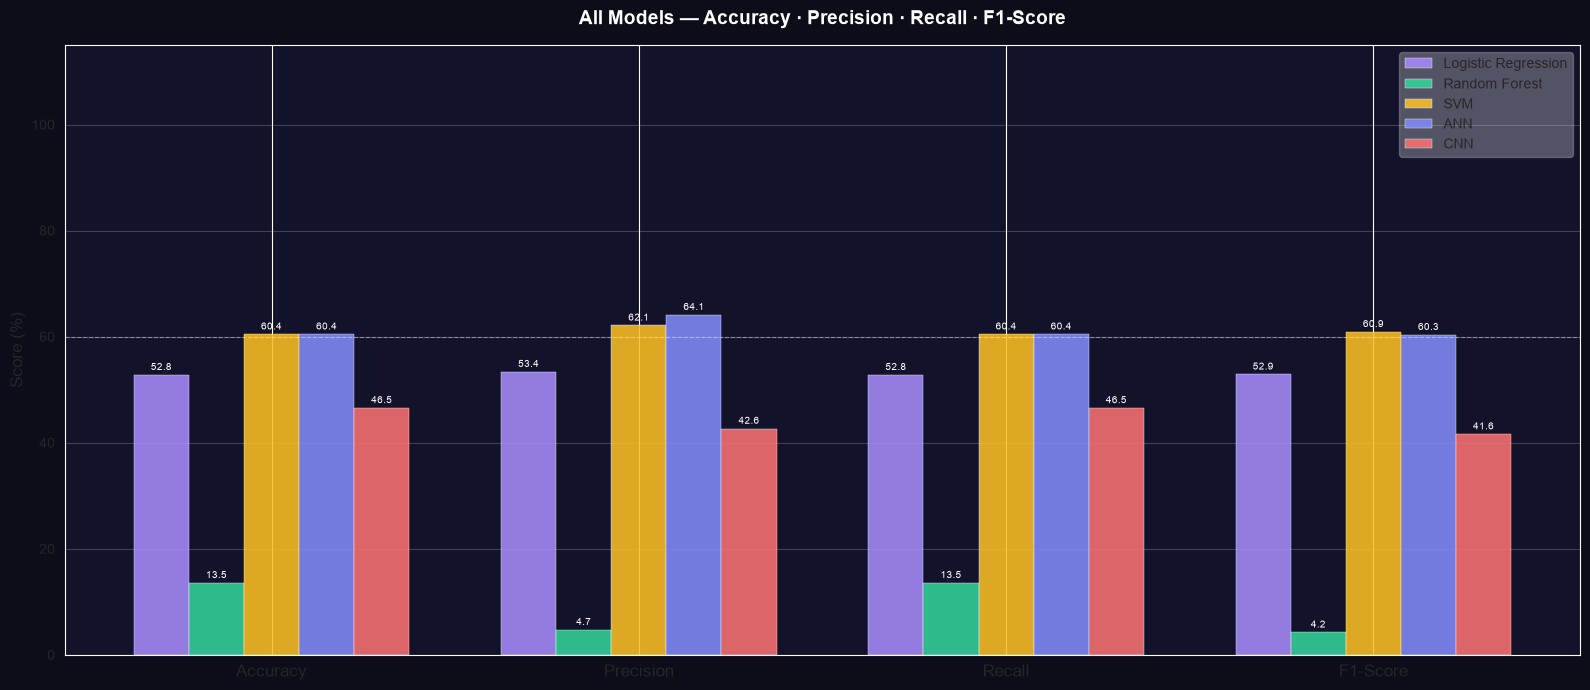

✅ Saved → C:\Speech Emotion Recognition\notebooks\..\reports\evaluation\all_models_metrics_bar.png


In [4]:
# ── Compute all scalar metrics ────────────────────────────────────────────────
rows = []
for name in MODEL_NAMES:
    yp = preds[name]
    rows.append({
        'Model'    : name,
        'Type'     : 'DL' if name in ('ANN','CNN') else 'ML',
        'Accuracy' : round(accuracy_score (y_test, yp),            4),
        'Precision': round(precision_score(y_test, yp, average='weighted', zero_division=0), 4),
        'Recall'   : round(recall_score   (y_test, yp, average='weighted', zero_division=0), 4),
        'F1'       : round(f1_score       (y_test, yp, average='weighted', zero_division=0), 4),
    })
metrics_df = pd.DataFrame(rows).set_index('Model')

# ── Print formatted table ─────────────────────────────────────────────────────
print('=' * 75)
print('   MODULE 9 — COMPREHENSIVE METRICS TABLE')
print('=' * 75)
print(f'{"Model":<22} {"Type":<5} {"Accuracy":>10} {"Precision":>11} {"Recall":>8} {"F1":>8}')
print('-' * 75)
for mname, r in metrics_df.iterrows():
    star = ' << BEST' if r['F1'] == metrics_df['F1'].max() else ''
    row_str = (f'{mname:<22} {r["Type"]:<5}'
               f' {r["Accuracy"]*100:9.2f}% {r["Precision"]*100:10.2f}%'
               f' {r["Recall"]*100:7.2f}% {r["F1"]*100:7.2f}%{star}')
    print(row_str)
print('=' * 75)
best_model = metrics_df['F1'].idxmax()
best_f1    = metrics_df.loc[best_model, 'F1']
print(f'\n  Best model: {best_model}  |  F1 = {best_f1*100:.2f}%')

# ── Visualise: grouped bar chart ──────────────────────────────────────────────
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metric_cols))
w = 0.15

fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor(DARK)
ax.set_facecolor(PANEL)

for k, name in enumerate(MODEL_NAMES):
    vals  = [metrics_df.loc[name, m] * 100 for m in metric_cols]
    bars  = ax.bar(x + (k - 2) * w, vals, w,
                   label=name, color=MODEL_COLORS[name],
                   alpha=0.88, edgecolor='white', linewidth=0.3)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
                f'{v:.1f}', ha='center', va='bottom', fontsize=7.5, color='white')

ax.set_xticks(x)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1-Score'], fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_ylim([0, 115])
ax.set_title('All Models — Accuracy · Precision · Recall · F1-Score',
             fontsize=14, fontweight='bold', color='white', pad=15)
ax.legend(fontsize=10, loc='upper right', framealpha=0.3)
ax.grid(axis='y', alpha=0.2)
ax.axhline(60, color='white', linestyle='--', linewidth=0.8, alpha=0.4)

plt.tight_layout()
path = os.path.join(REP_DIR, 'all_models_metrics_bar.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print(f'✅ Saved → {path}')

## 9.5 — Confusion Matrices — 5-Model Grid View

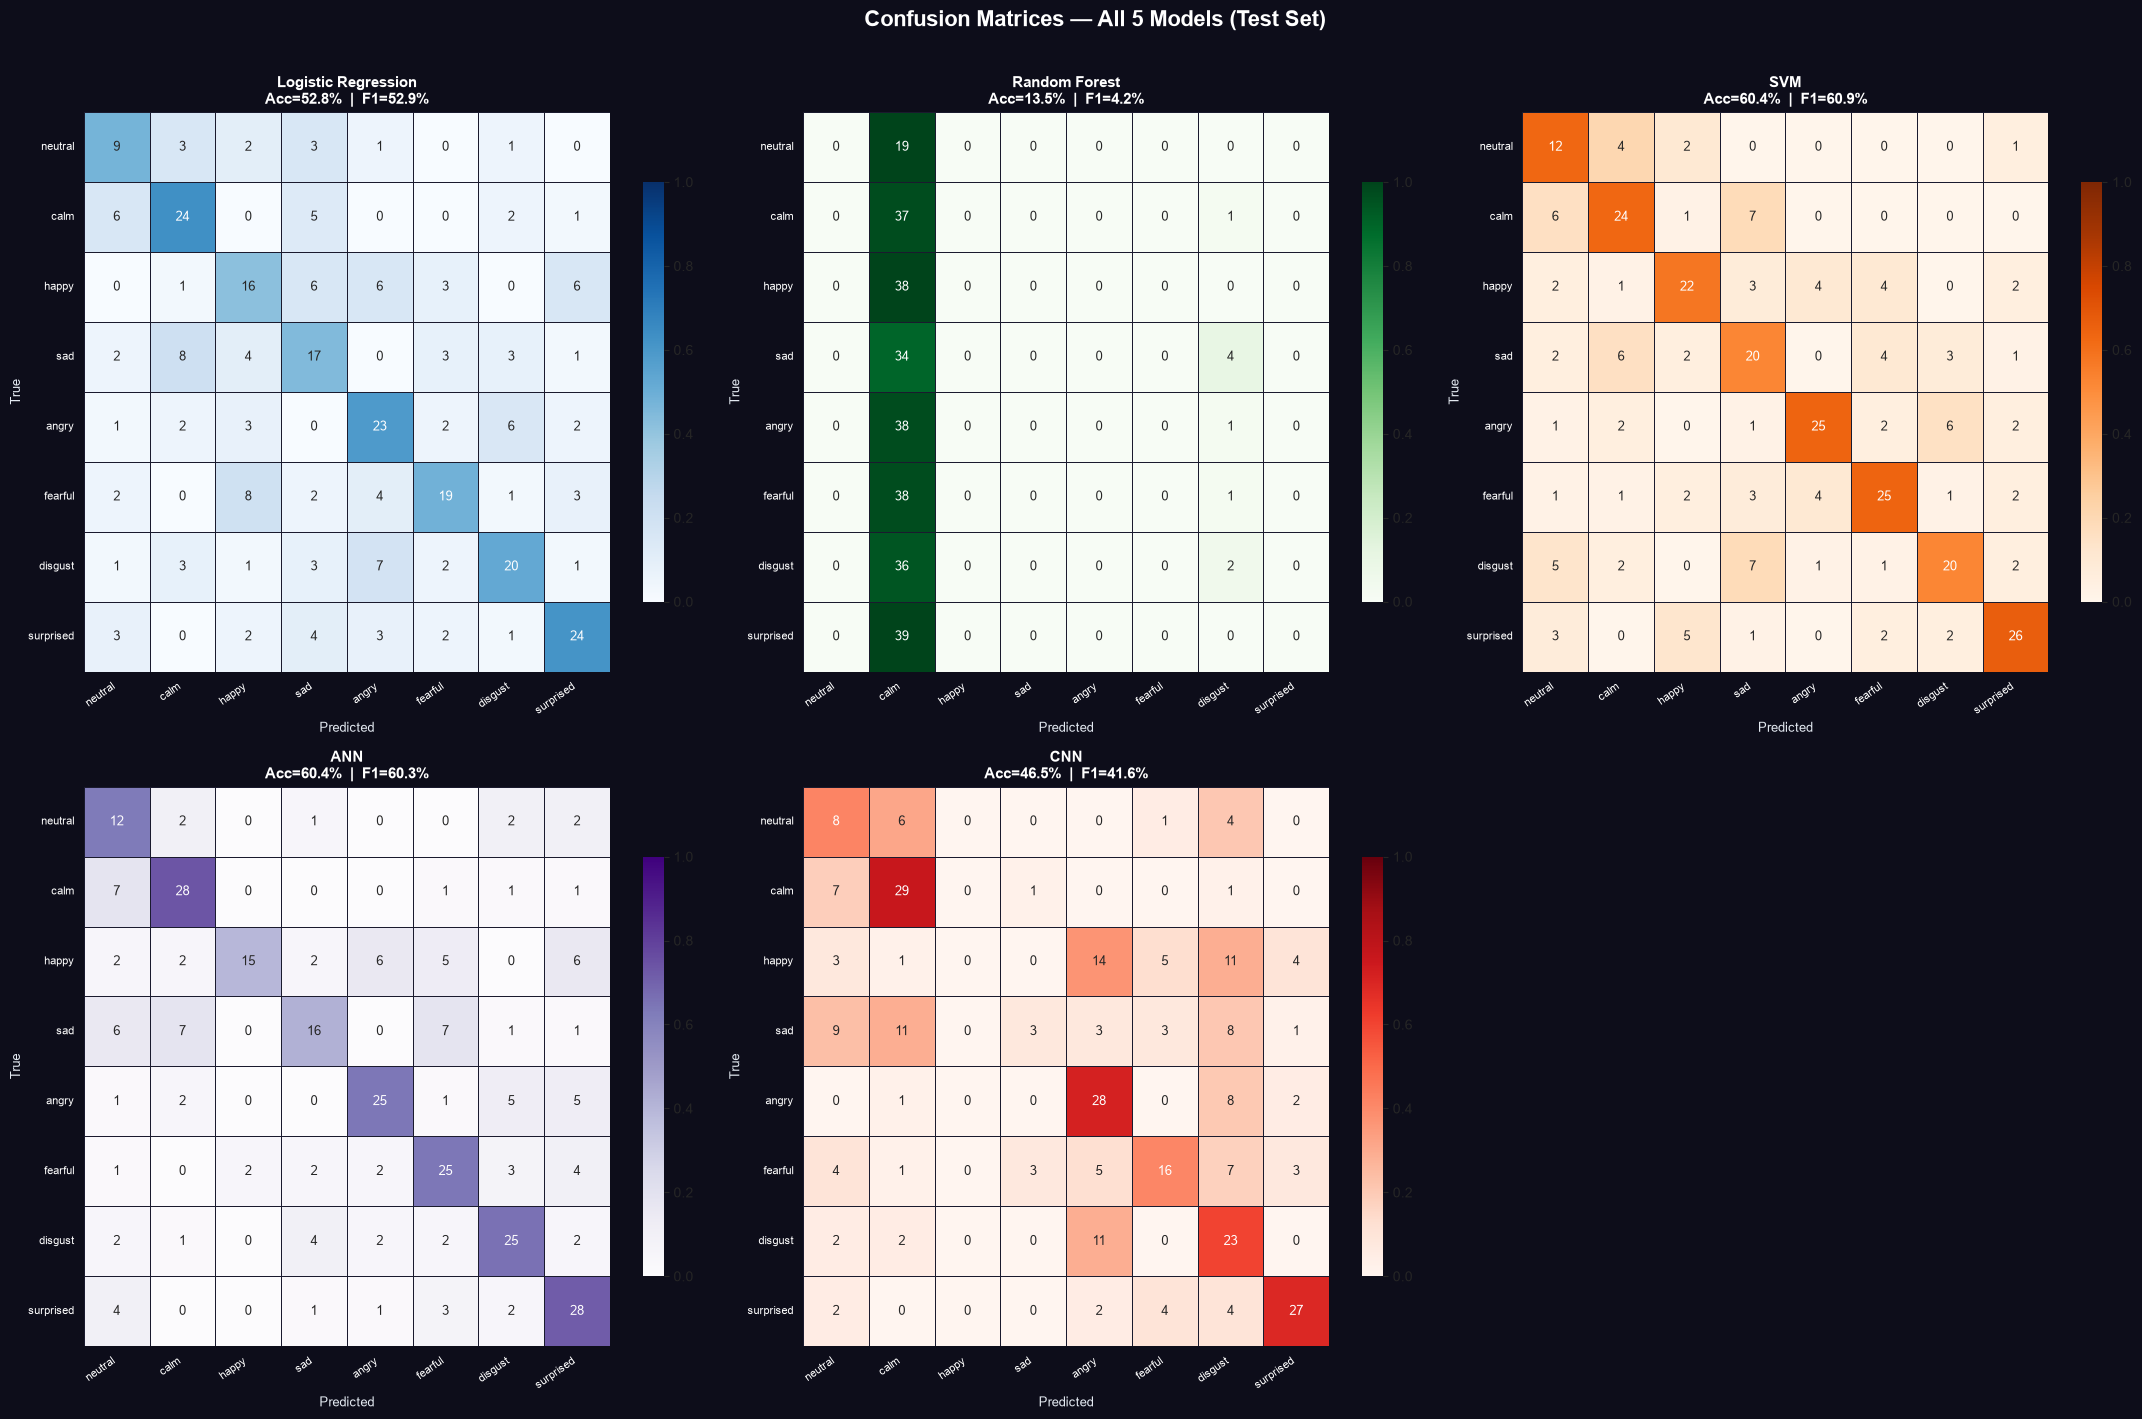

✅ Saved → C:\Speech Emotion Recognition\notebooks\..\reports\evaluation\confusion_matrices_all_models.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.patch.set_facecolor(DARK)
fig.suptitle('Confusion Matrices — All 5 Models (Test Set)',
             fontsize=16, fontweight='bold', color='white', y=1.01)

cmaps = ['Blues', 'Greens', 'Oranges', 'Purples', 'Reds']

for idx, (name, cmap_) in enumerate(zip(MODEL_NAMES, cmaps)):
    row, col = divmod(idx, 3)
    ax = axes[row][col]
    ax.set_facecolor(PANEL)

    cm = confusion_matrix(y_test, preds[name])
    # Normalise row-wise for clarity
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap=cmap_,
                xticklabels=EMOTIONS, yticklabels=EMOTIONS,
                ax=ax, linewidths=0.4, linecolor='#1a1a2e',
                annot_kws={'size': 9}, cbar_kws={'shrink': 0.75},
                vmin=0, vmax=1)

    acc = accuracy_score(y_test, preds[name])
    f1  = f1_score(y_test, preds[name], average='weighted', zero_division=0)
    ax.set_title(f'{name}\nAcc={acc*100:.1f}%  |  F1={f1*100:.1f}%',
                 color='white', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=9, color=TEXT)
    ax.set_ylabel('True',      fontsize=9, color=TEXT)
    ax.tick_params(colors='white', labelsize=8)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', color='white')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  color='white')

# hide unused subplot
axes[1][2].set_visible(False)

plt.tight_layout()
path = os.path.join(REP_DIR, 'confusion_matrices_all_models.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print(f'✅ Saved → {path}')

## 9.6 — Classification Reports

In [6]:
# ── Print full classification report for each model ───────────────────────────
all_reports = {}
for name in MODEL_NAMES:
    cr = classification_report(
        y_test, preds[name],
        target_names=EMOTIONS, zero_division=0, output_dict=True)
    all_reports[name] = cr

    print(f'\n{"═"*62}')
    print(f'  {name} — Classification Report')
    print(f'{"═"*62}')
    print(classification_report(y_test, preds[name],
                                 target_names=EMOTIONS, zero_division=0))

print('✅ All classification reports printed.')


══════════════════════════════════════════════════════════════
  Logistic Regression — Classification Report
══════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

     neutral       0.38      0.47      0.42        19
        calm       0.59      0.63      0.61        38
       happy       0.44      0.42      0.43        38
         sad       0.42      0.45      0.44        38
       angry       0.52      0.59      0.55        39
     fearful       0.61      0.49      0.54        39
     disgust       0.59      0.53      0.56        38
   surprised       0.63      0.62      0.62        39

    accuracy                           0.53       288
   macro avg       0.52      0.52      0.52       288
weighted avg       0.53      0.53      0.53       288


══════════════════════════════════════════════════════════════
  Random Forest — Classification Report
══════════════════════════════════════════════════════════════
         


══════════════════════════════════════════════════════════════
  CNN — Classification Report
══════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

     neutral       0.23      0.42      0.30        19
        calm       0.57      0.76      0.65        38
       happy       0.00      0.00      0.00        38
         sad       0.43      0.08      0.13        38
       angry       0.44      0.72      0.55        39
     fearful       0.55      0.41      0.47        39
     disgust       0.35      0.61      0.44        38
   surprised       0.73      0.69      0.71        39

    accuracy                           0.47       288
   macro avg       0.41      0.46      0.41       288
weighted avg       0.43      0.47      0.42       288

✅ All classification reports printed.


## 9.7 — Per-Class F1 Heatmap

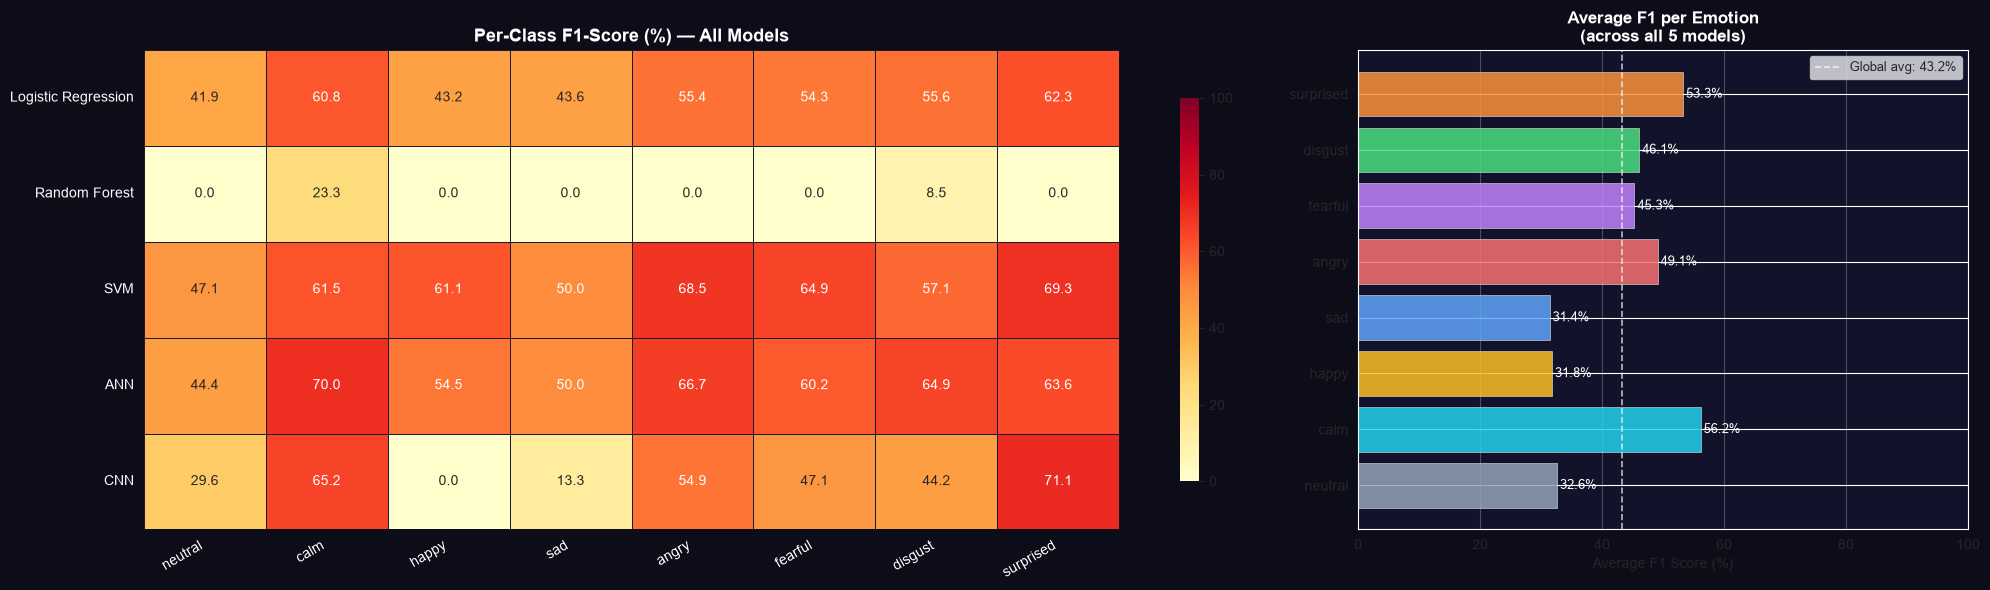


✅ Saved → C:\Speech Emotion Recognition\notebooks\..\reports\evaluation\per_class_f1_heatmap.png

📌 Hardest emotions to classify (lowest avg F1):
   sad          → 31.4%
   happy        → 31.8%
   neutral      → 32.6%

📌 Easiest emotions to classify (highest avg F1):
   calm         → 56.2%
   surprised    → 53.3%
   angry        → 49.1%


In [7]:
# ── Build per-class F1 matrix  (5 models × 8 emotions) ───────────────────────
f1_matrix = np.zeros((len(MODEL_NAMES), N_CLASSES))
for i, name in enumerate(MODEL_NAMES):
    f1_matrix[i] = f1_score(y_test, preds[name],
                             average=None, labels=range(N_CLASSES), zero_division=0)

f1_df = pd.DataFrame(f1_matrix * 100,
                      index=MODEL_NAMES, columns=EMOTIONS)

fig, axes = plt.subplots(1, 2, figsize=(20, 6), gridspec_kw={'width_ratios': [2, 1]})
fig.patch.set_facecolor(DARK)

# ── Heatmap ───────────────────────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor(PANEL)
sns.heatmap(f1_df, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=ax, linewidths=0.5, linecolor='#1a1a2e',
            annot_kws={'size': 10}, cbar_kws={'shrink': 0.8},
            vmin=0, vmax=100)
ax.set_title('Per-Class F1-Score (%) — All Models',
             color='white', fontsize=13, fontweight='bold')
ax.tick_params(colors='white', labelsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', color='white')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  color='white')
ax.set_xlabel('')
ax.set_ylabel('')

# ── Avg F1 per emotion (radar-like bar) ───────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor(PANEL)
avg_f1 = f1_df.mean(axis=0)
clrs   = [ECOLORS[e] for e in EMOTIONS]
bars   = ax2.barh(EMOTIONS, avg_f1, color=clrs,
                   alpha=0.85, edgecolor='white', linewidth=0.4)
for bar, val in zip(bars, avg_f1):
    ax2.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9, color='white')
ax2.set_xlim([0, 100])
ax2.set_xlabel('Average F1 Score (%)', fontsize=10)
ax2.set_title('Average F1 per Emotion\n(across all 5 models)',
              color='white', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.25)
ax2.axvline(avg_f1.mean(), color='white', linestyle='--',
             linewidth=1.2, alpha=0.7, label=f'Global avg: {avg_f1.mean():.1f}%')
ax2.legend(fontsize=9)

plt.tight_layout()
path = os.path.join(REP_DIR, 'per_class_f1_heatmap.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()

print(f'\n✅ Saved → {path}')
print('\n📌 Hardest emotions to classify (lowest avg F1):')
for e, v in avg_f1.sort_values().head(3).items():
    print(f'   {e:<12} → {v:.1f}%')
print('\n📌 Easiest emotions to classify (highest avg F1):')
for e, v in avg_f1.sort_values(ascending=False).head(3).items():
    print(f'   {e:<12} → {v:.1f}%')

## 9.8 — ROC / AUC Curves (One-vs-Rest)

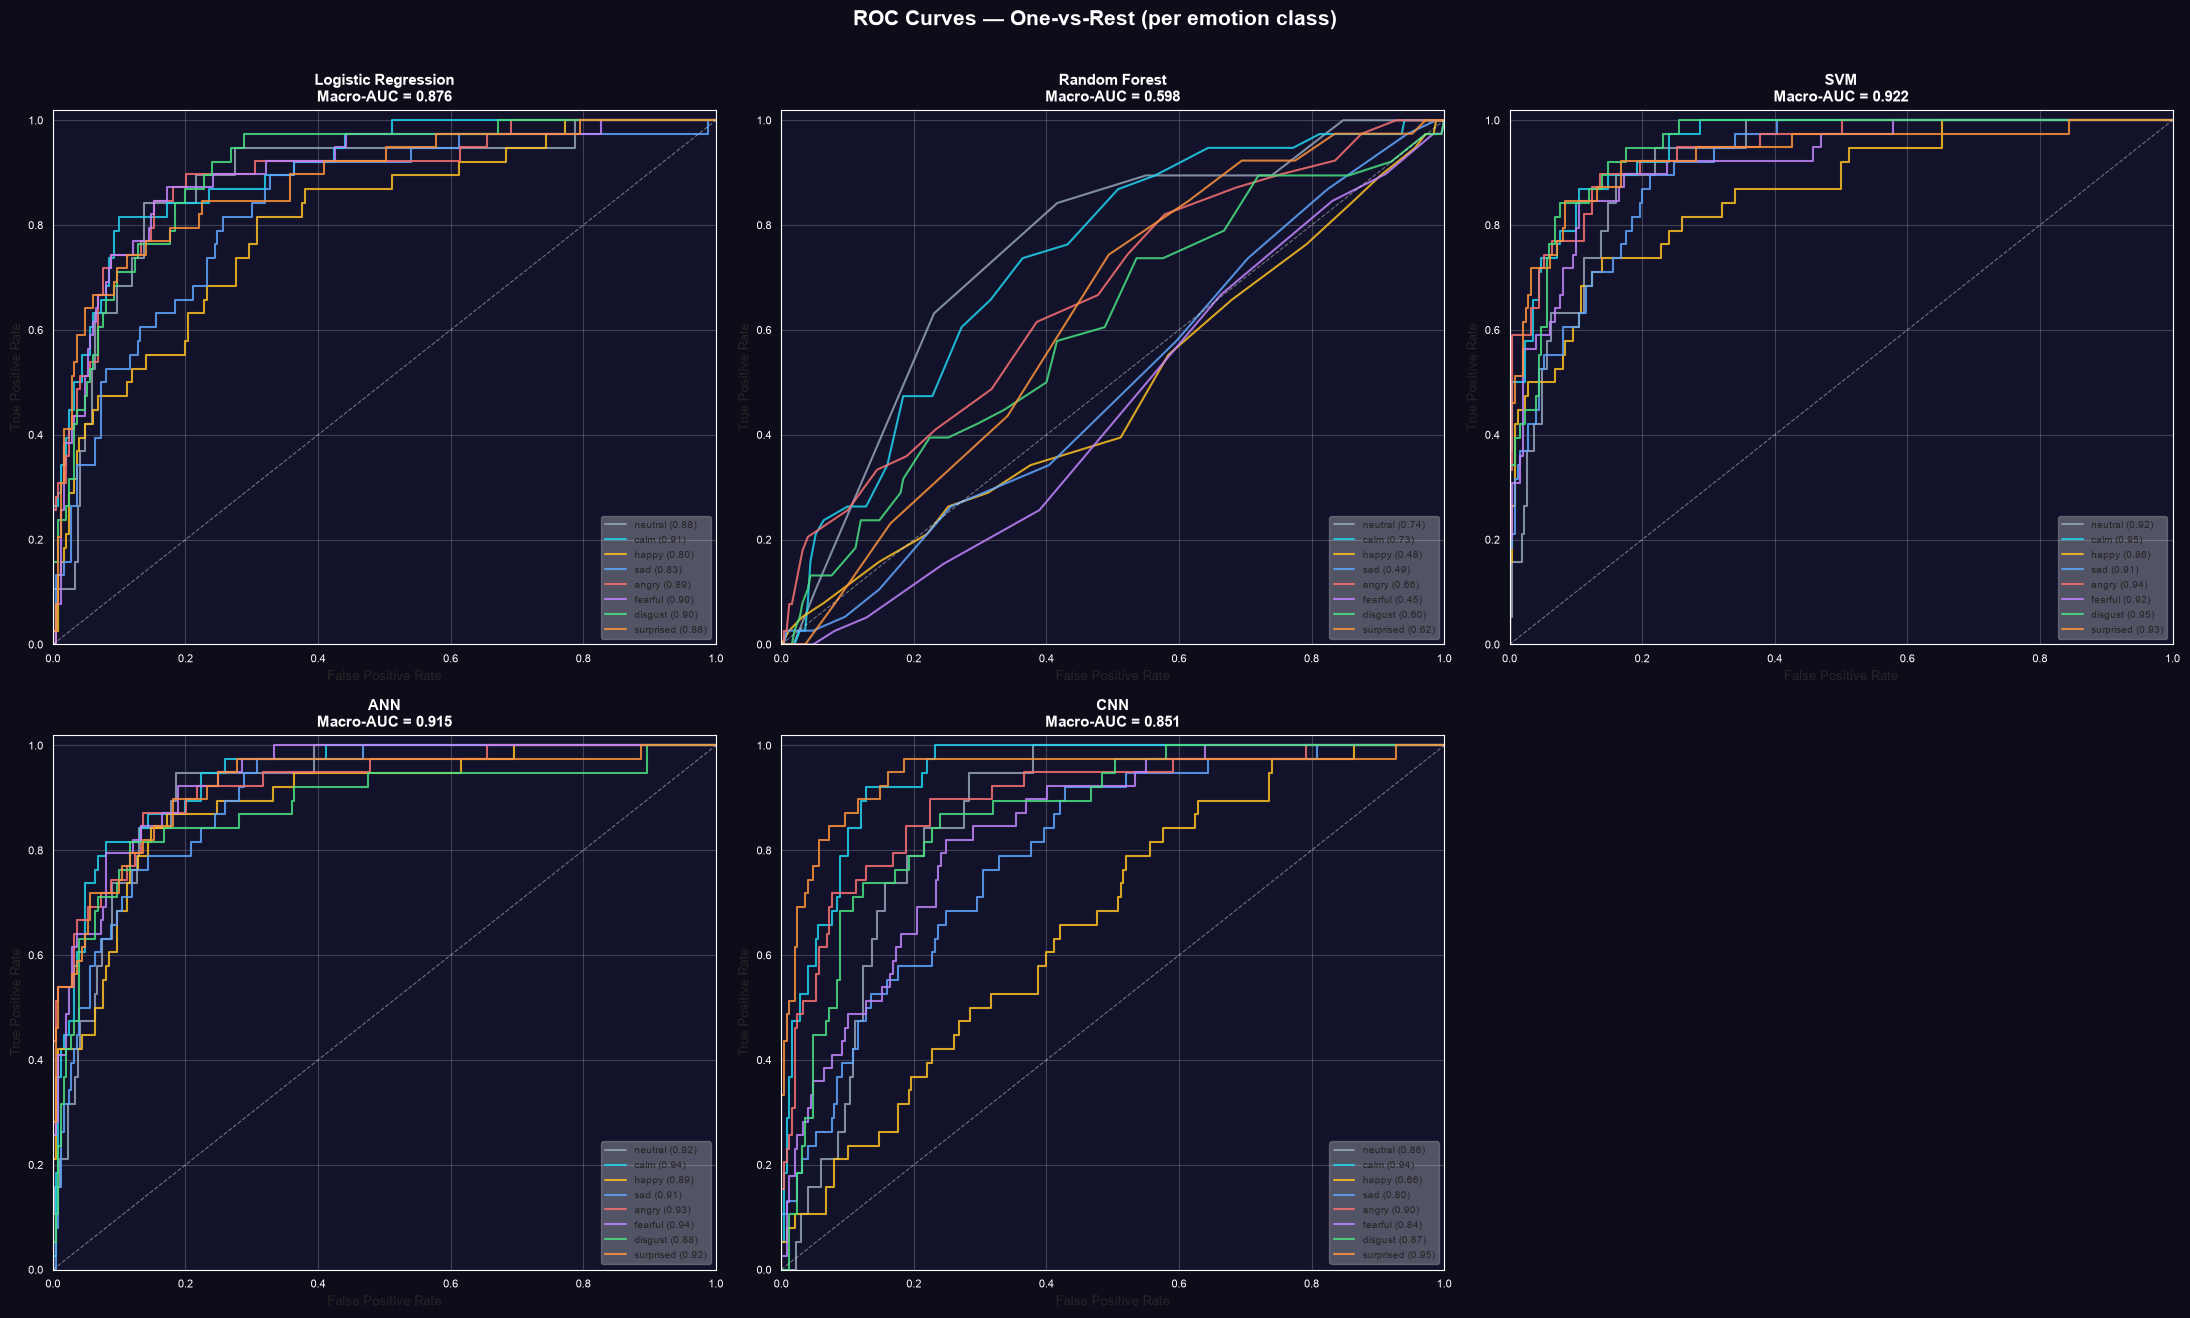

✅ Saved → C:\Speech Emotion Recognition\notebooks\..\reports\evaluation\roc_curves_all_models.png

📊 Macro-AUC Summary:
Model                      Macro-AUC
-------------------------------------
  Logistic Regression      0.8755


  Random Forest            0.5975


  SVM                      0.9219 ◀ BEST
  ANN                      0.9154


  CNN                      0.8510


In [8]:
# ── One-hot encode ground truth ───────────────────────────────────────────────
y_bin = label_binarize(y_test, classes=range(N_CLASSES))  # (N, 8)

fig, axes = plt.subplots(2, 3, figsize=(22, 13))
fig.patch.set_facecolor(DARK)
fig.suptitle('ROC Curves — One-vs-Rest (per emotion class)',
             fontsize=15, fontweight='bold', color='white', y=1.01)

for idx, (name, col) in enumerate(zip(MODEL_NAMES, MODEL_COLORS.values())):
    row_, col_ = divmod(idx, 3)
    ax = axes[row_][col_]
    ax.set_facecolor(PANEL)

    macro_auc_vals = []
    for cls_idx, emotion in enumerate(EMOTIONS):
        fpr, tpr, _ = roc_curve(y_bin[:, cls_idx], proba[name][:, cls_idx])
        roc_auc      = auc(fpr, tpr)
        macro_auc_vals.append(roc_auc)
        ax.plot(fpr, tpr, linewidth=1.5, alpha=0.85,
                color=ECOLORS[emotion],
                label=f'{emotion} ({roc_auc:.2f})')

    ax.plot([0,1],[0,1], 'w--', linewidth=0.8, alpha=0.4)
    macro_auc = np.mean(macro_auc_vals)
    ax.set_title(f'{name}\nMacro-AUC = {macro_auc:.3f}',
                 color='white', fontsize=11, fontweight='bold')
    ax.set_xlabel('False Positive Rate', fontsize=9)
    ax.set_ylabel('True Positive Rate',  fontsize=9)
    ax.legend(fontsize=7.5, loc='lower right', framealpha=0.3)
    ax.grid(alpha=0.2)
    ax.tick_params(colors='white', labelsize=8)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])

axes[1][2].set_visible(False)
plt.tight_layout()
path = os.path.join(REP_DIR, 'roc_curves_all_models.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print(f'✅ Saved → {path}')

# ── Print AUC summary table ───────────────────────────────────────────────────
print('\n📊 Macro-AUC Summary:')
print(f'{"Model":<25}  Macro-AUC')
print('-' * 37)
for name in MODEL_NAMES:
    aucs = []
    for ci in range(N_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, ci], proba[name][:, ci])
        aucs.append(auc(fpr, tpr))
    star = ' ◀ BEST' if name == MODEL_NAMES[np.argmax(
        [np.mean([auc(roc_curve(y_bin[:,ci], proba[n][:,ci])[0],
                       roc_curve(y_bin[:,ci], proba[n][:,ci])[1])
                   for ci in range(N_CLASSES)])
         for n in MODEL_NAMES])] else ''
    print(f'  {name:<23}  {np.mean(aucs):.4f}{star}')

## 9.9 — Error Analysis: Misclassified Samples

🔍 Error Analysis for Best Model: SVM
   Total test samples : 288
   Correctly classified: 174 (60.4%)
   Misclassified      : 114  (39.6%)

📌 Top-15 most common confusion pairs (True → Predicted):
True Emotion    → Predicted         Count
---------------------------------------------
  disgust       → sad               7
  calm          → sad               7
  angry         → disgust           6
  sad           → calm              6
  calm          → neutral           6
  disgust       → neutral           5
  surprised     → happy             5
  neutral       → calm              4
  sad           → fearful           4
  happy         → angry             4
  happy         → fearful           4
  fearful       → angry             4
  surprised     → neutral           3
  sad           → disgust           3
  fearful       → sad               3


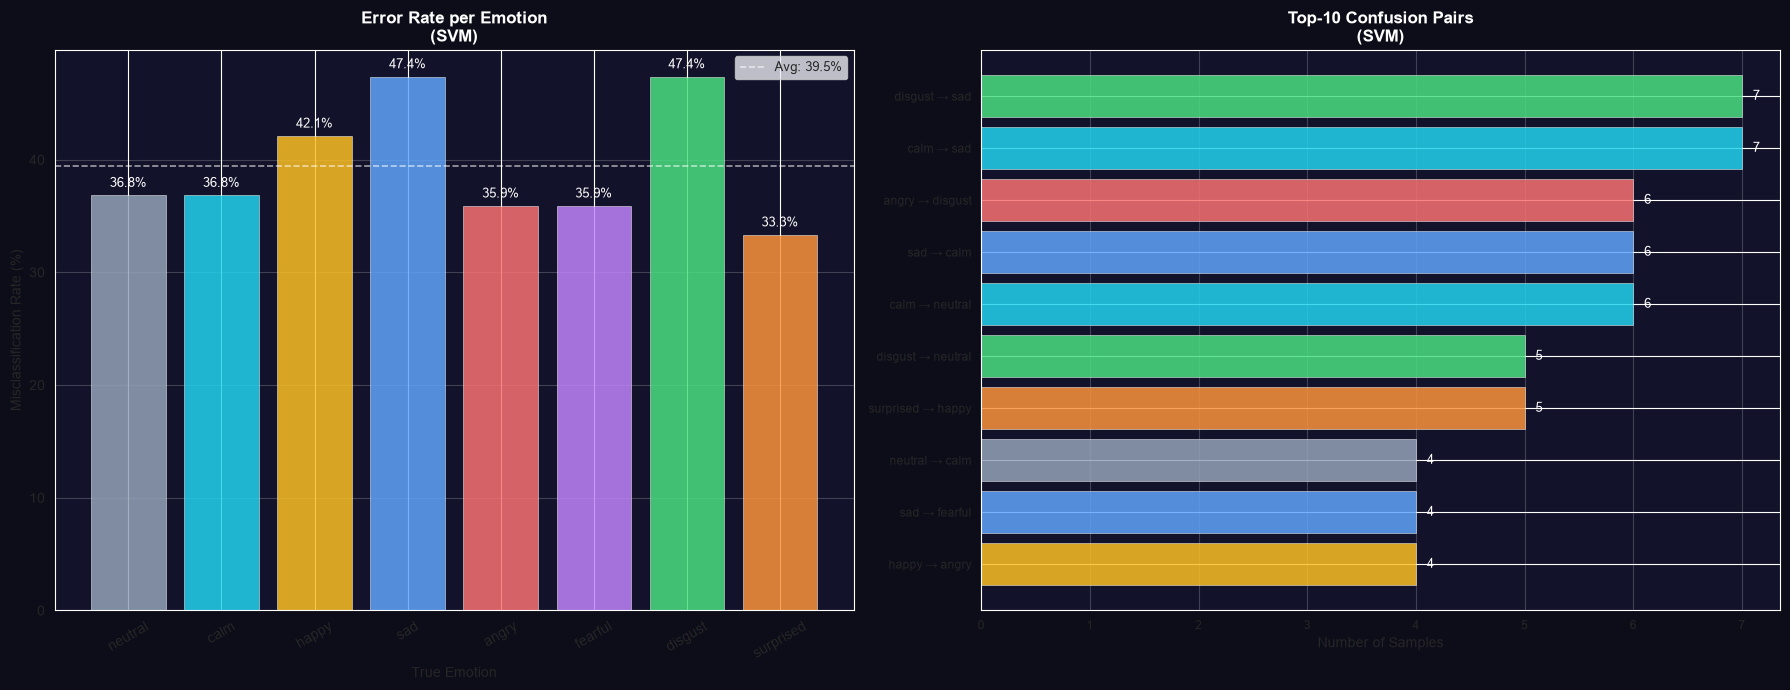


✅ Saved → C:\Speech Emotion Recognition\notebooks\..\reports\evaluation\error_analysis.png


In [9]:
# ── Focus on the best model (ANN) for deep error analysis ────────────────────
best_name = metrics_df['F1'].idxmax()
y_pred_best = preds[best_name]

errors = np.where(y_pred_best != y_test)[0]
correct = np.where(y_pred_best == y_test)[0]

print(f'🔍 Error Analysis for Best Model: {best_name}')
print(f'   Total test samples : {len(y_test)}')
print(f'   Correctly classified: {len(correct)} ({len(correct)/len(y_test)*100:.1f}%)')
print(f'   Misclassified      : {len(errors)}  ({len(errors)/len(y_test)*100:.1f}%)')

# ── Confusion pairs (what got confused with what?) ────────────────────────────
confusion_pairs = []
for i in errors:
    confusion_pairs.append((EMOTIONS[y_test[i]], EMOTIONS[y_pred_best[i]]))

from collections import Counter
pair_counts = Counter(confusion_pairs).most_common(15)

print(f'\n📌 Top-15 most common confusion pairs (True → Predicted):')
print(f'{"True Emotion":<15} → {"Predicted":<15}   Count')
print('-' * 45)
for (true, pred), cnt in pair_counts:
    print(f'  {true:<13} → {pred:<15}   {cnt}')

# ── Error breakdown per emotion ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor(DARK)

# Error rate per true emotion
ax = axes[0]
ax.set_facecolor(PANEL)
error_rates = []
for ci, emo in enumerate(EMOTIONS):
    mask = y_test == ci
    err  = (y_pred_best[mask] != ci).sum() / mask.sum() * 100
    error_rates.append(err)

clrs = [ECOLORS[e] for e in EMOTIONS]
bars = ax.bar(EMOTIONS, error_rates, color=clrs,
               alpha=0.85, edgecolor='white', linewidth=0.4)
for b, v in zip(bars, error_rates):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=9, color='white')
ax.set_title(f'Error Rate per Emotion\n({best_name})',
             color='white', fontsize=12, fontweight='bold')
ax.set_ylabel('Misclassification Rate (%)', fontsize=10)
ax.set_xlabel('True Emotion', fontsize=10)
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.2)
ax.axhline(np.mean(error_rates), color='white', linestyle='--',
            linewidth=1.2, alpha=0.6, label=f'Avg: {np.mean(error_rates):.1f}%')
ax.legend(fontsize=9)

# Top confusion pairs - horizontal bar
ax2 = axes[1]
ax2.set_facecolor(PANEL)
top_pairs = pair_counts[:10]
labels = [f'{t} → {p}' for (t,p),_ in top_pairs]
counts = [c for _,c in top_pairs]
colors_bar = [ECOLORS.get(t, '#818cf8') for (t,p),_ in top_pairs]
bars2 = ax2.barh(labels[::-1], counts[::-1], color=colors_bar[::-1],
                  alpha=0.85, edgecolor='white', linewidth=0.4)
for bar, v in zip(bars2, counts[::-1]):
    ax2.text(v+0.1, bar.get_y()+bar.get_height()/2,
             str(v), va='center', fontsize=9, color='white')
ax2.set_xlabel('Number of Samples', fontsize=10)
ax2.set_title(f'Top-10 Confusion Pairs\n({best_name})',
              color='white', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.2)
ax2.tick_params(labelsize=8.5)

plt.tight_layout()
path = os.path.join(REP_DIR, 'error_analysis.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print(f'\n✅ Saved → {path}')

## 9.10 — ML vs Deep Learning Comparison Dashboard

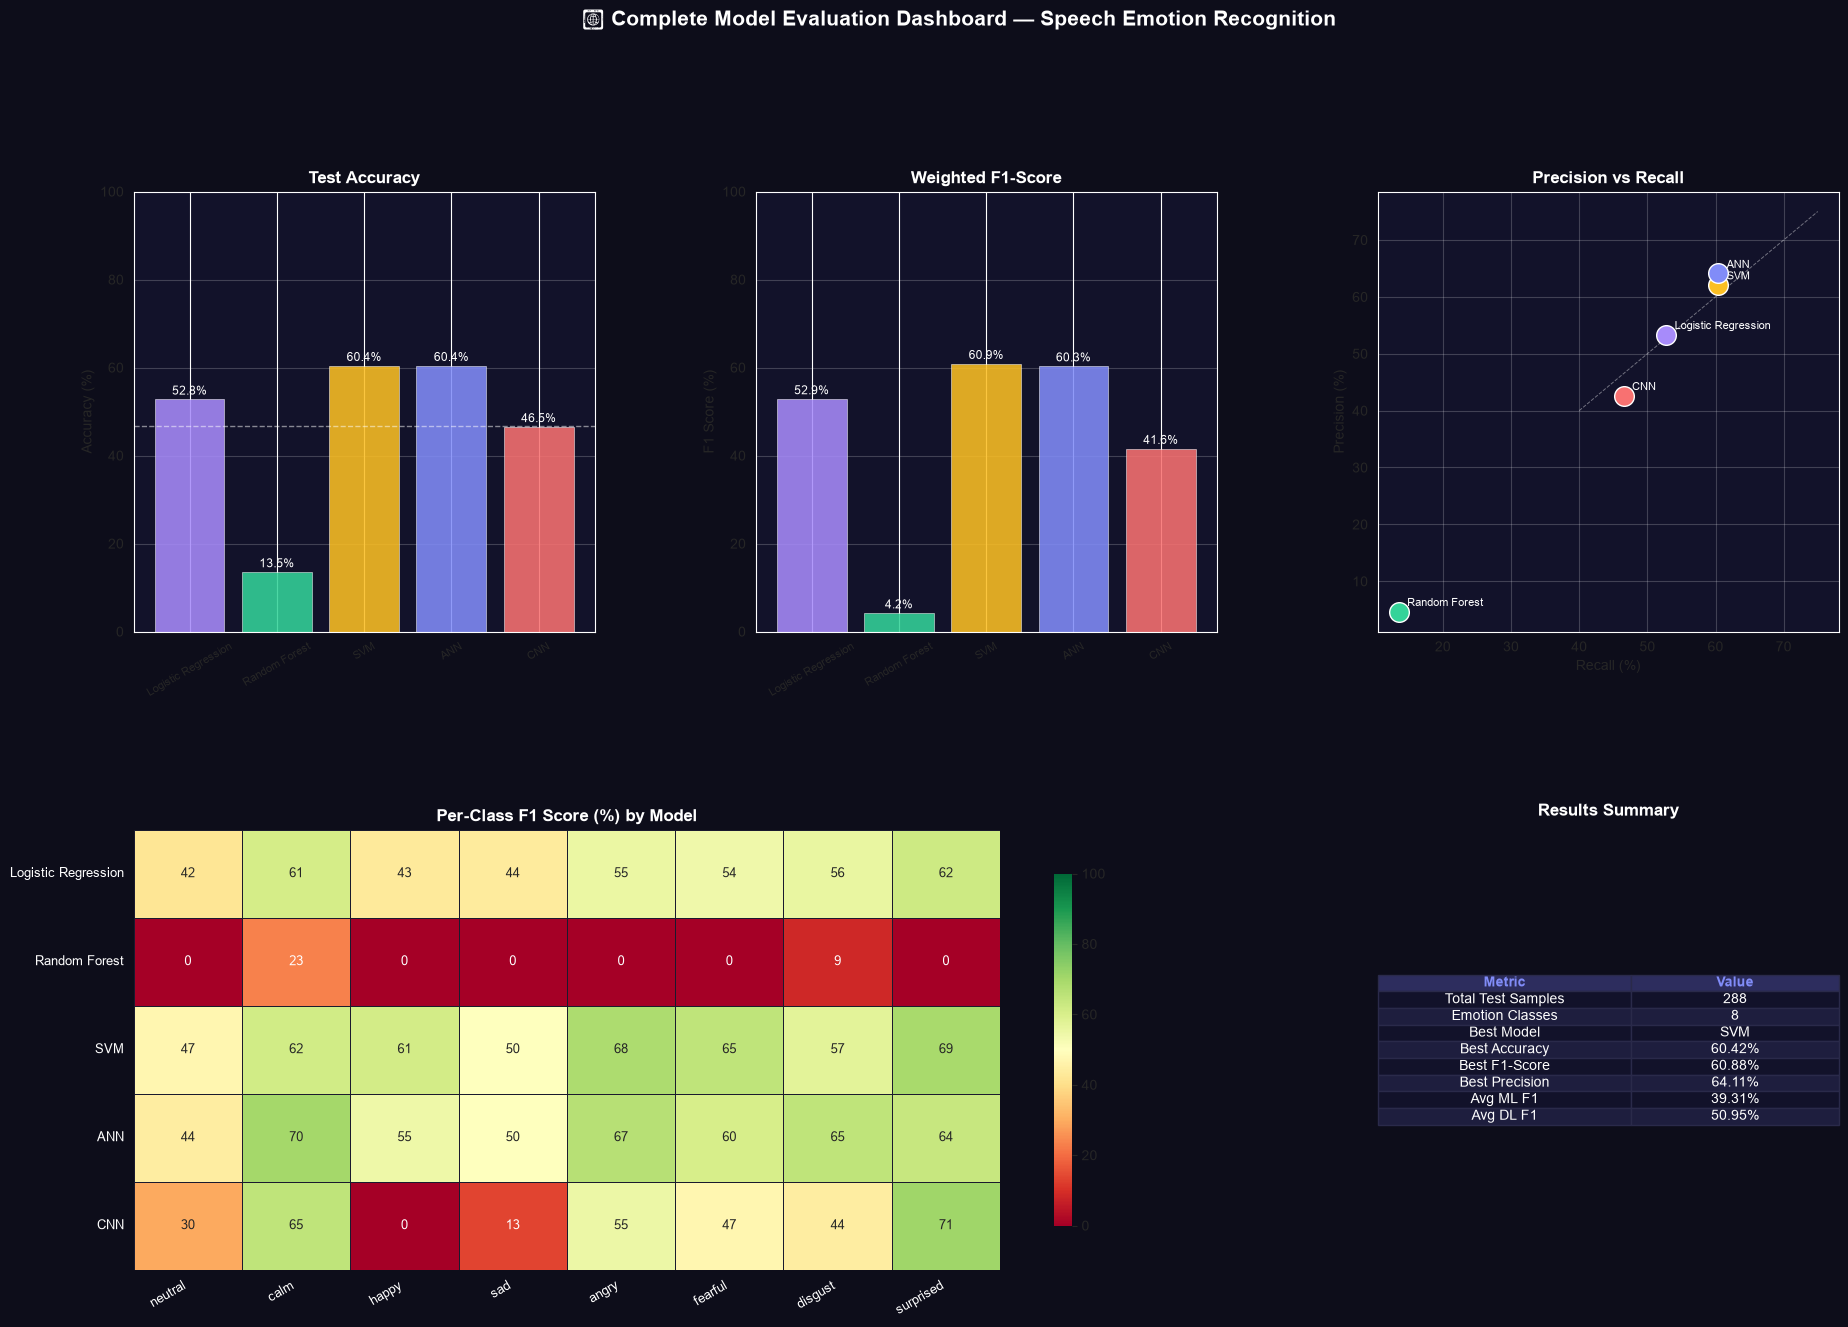

✅ Saved → C:\Speech Emotion Recognition\notebooks\..\reports\evaluation\complete_evaluation_dashboard.png


In [10]:
fig = plt.figure(figsize=(22, 14))
fig.patch.set_facecolor(DARK)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('📊 Complete Model Evaluation Dashboard — Speech Emotion Recognition',
             fontsize=15, fontweight='bold', color='white', y=1.01)

# ── Panel 1: Overall accuracy bar ────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(PANEL)
accs   = [metrics_df.loc[n,'Accuracy']*100 for n in MODEL_NAMES]
cols   = [MODEL_COLORS[n] for n in MODEL_NAMES]
bars   = ax1.bar(MODEL_NAMES, accs, color=cols, alpha=0.88,
                  edgecolor='white', linewidth=0.4)
for b, v in zip(bars, accs):
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
             f'{v:.1f}%', ha='center', va='bottom', fontsize=8.5, color='white')
ax1.set_title('Test Accuracy', color='white', fontsize=12, fontweight='bold')
ax1.set_ylim([0, 100])
ax1.set_ylabel('Accuracy (%)')
ax1.tick_params(axis='x', rotation=30, labelsize=8)
ax1.grid(axis='y', alpha=0.2)
ax1.axhline(np.mean(accs), color='white', linestyle='--', linewidth=1, alpha=0.5)

# ── Panel 2: F1-Score bar ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(PANEL)
f1s  = [metrics_df.loc[n,'F1']*100 for n in MODEL_NAMES]
bars = ax2.bar(MODEL_NAMES, f1s, color=cols, alpha=0.88,
                edgecolor='white', linewidth=0.4)
for b, v in zip(bars, f1s):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
             f'{v:.1f}%', ha='center', va='bottom', fontsize=8.5, color='white')
ax2.set_title('Weighted F1-Score', color='white', fontsize=12, fontweight='bold')
ax2.set_ylim([0, 100])
ax2.set_ylabel('F1 Score (%)')
ax2.tick_params(axis='x', rotation=30, labelsize=8)
ax2.grid(axis='y', alpha=0.2)

# ── Panel 3: Precision vs Recall scatter ──────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor(PANEL)
for name in MODEL_NAMES:
    p = metrics_df.loc[name,'Precision']*100
    r = metrics_df.loc[name,'Recall']*100
    ax3.scatter(r, p, color=MODEL_COLORS[name], s=200, zorder=5,
                edgecolors='white', linewidth=1)
    ax3.annotate(name, (r, p), textcoords='offset points',
                  xytext=(6,4), fontsize=8, color='white')
ax3.set_xlabel('Recall (%)', fontsize=10)
ax3.set_ylabel('Precision (%)', fontsize=10)
ax3.set_title('Precision vs Recall', color='white', fontsize=12, fontweight='bold')
ax3.grid(alpha=0.2)
ax3.plot([40,75],[40,75], 'w--', linewidth=0.7, alpha=0.4)

# ── Panel 4: Per-class best model heatmap ────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0:2])
ax4.set_facecolor(PANEL)
sns.heatmap(f1_df, annot=True, fmt='.0f', cmap='RdYlGn',
            ax=ax4, linewidths=0.4, linecolor='#1a1a2e',
            annot_kws={'size': 9}, cbar_kws={'shrink': 0.8},
            vmin=0, vmax=100)
ax4.set_title('Per-Class F1 Score (%) by Model',
              color='white', fontsize=12, fontweight='bold')
ax4.tick_params(colors='white', labelsize=9)
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=30, ha='right', color='white')
ax4.set_yticklabels(ax4.get_yticklabels(), rotation=0,  color='white')

# ── Panel 5: Summary stats table ─────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.set_facecolor(CARD)
ax5.axis('off')
summary_lines = [
    ['Metric', 'Value'],
    ['Total Test Samples', f'{len(y_test)}'],
    ['Emotion Classes', f'{N_CLASSES}'],
    ['Best Model', best_name],
    ['Best Accuracy', f'{metrics_df["Accuracy"].max()*100:.2f}%'],
    ['Best F1-Score', f'{metrics_df["F1"].max()*100:.2f}%'],
    ['Best Precision', f'{metrics_df["Precision"].max()*100:.2f}%'],
    ['Avg ML F1', f'{metrics_df[metrics_df["Type"]=="ML"]["F1"].mean()*100:.2f}%'],
    ['Avg DL F1', f'{metrics_df[metrics_df["Type"]=="DL"]["F1"].mean()*100:.2f}%'],
]
tbl = ax5.table(cellText=summary_lines[1:], colLabels=summary_lines[0],
                 cellLoc='center', loc='center',
                 colWidths=[0.55, 0.45])
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
for (r,c), cell in tbl.get_celld().items():
    cell.set_facecolor('#1e1e3e' if r % 2 == 0 else '#12122a')
    cell.set_text_props(color='white')
    cell.set_edgecolor('#2a2a4a')
    if r == 0:
        cell.set_facecolor('#2d2d5e')
        cell.set_text_props(color='#818cf8', fontweight='bold')
ax5.set_title('Results Summary', color='white', fontsize=12,
               fontweight='bold', pad=10)

path = os.path.join(REP_DIR, 'complete_evaluation_dashboard.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print(f'✅ Saved → {path}')

## 9.11 — Save Evaluation Results & Module 9 Summary

In [11]:
# ── Save per-class F1 CSV ─────────────────────────────────────────────────────
f1_df.to_csv(os.path.join(REP_DIR, 'per_class_f1_all_models.csv'))

# ── Save metrics CSV ──────────────────────────────────────────────────────────
metrics_df.reset_index().to_csv(
    os.path.join(REP_DIR, 'm9_metrics_summary.csv'), index=False)

# ── Save macro-AUC per model ──────────────────────────────────────────────────
auc_rows = []
for name in MODEL_NAMES:
    aucs = []
    for ci in range(N_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, ci], proba[name][:, ci])
        aucs.append(auc(fpr, tpr))
    auc_rows.append({'Model': name, 'Macro_AUC': round(np.mean(aucs), 4)})
auc_df = pd.DataFrame(auc_rows)
auc_df.to_csv(os.path.join(REP_DIR, 'macro_auc_all_models.csv'), index=False)

# ── Final summary print ───────────────────────────────────────────────────────
print('=' * 72)
print('   MODULE 9 — MODEL EVALUATION COMPLETE')
print('=' * 72)
print(f'\n  {"Model":<22} {"Type":<5} {"Acc":>7} {"Prec":>7} {"Rec":>7} {"F1":>7} {"AUC":>7}')
print('  ' + '-' * 68)
for mname, row in metrics_df.iterrows():
    auc_val  = auc_df.loc[auc_df['Model'] == mname, 'Macro_AUC'].values[0]
    star     = ' BEST' if mname == best_name else ''
    row_str  = (f'  {mname:<22} {row["Type"]:<5}'
                f' {row["Accuracy"]*100:6.1f}% {row["Precision"]*100:6.1f}%'
                f' {row["Recall"]*100:6.1f}% {row["F1"]*100:6.1f}% {auc_val:6.3f}{star}')
    print(row_str)
print('=' * 72)

ml_avg  = metrics_df[metrics_df['Type']=='ML']['F1'].mean()*100
dl_avg  = metrics_df[metrics_df['Type']=='DL']['F1'].mean()*100
dl_gain = dl_avg - ml_avg

print(f'\n  Average ML F1  : {ml_avg:.2f}%')
print(f'  Average DL F1  : {dl_avg:.2f}%')
print(f'  DL vs ML gain  : {dl_gain:+.2f}%')
print(f'\n  Best overall   : {best_name}  (F1={metrics_df.loc[best_name,"F1"]*100:.2f}%)')
print(f'\n  Saved files in : {REP_DIR}')
print(f'  Reports generated:')
for f in sorted(os.listdir(REP_DIR)):
    print(f'    · {f}')
print('\n✅ Module 9 Complete — All Evaluation Artifacts Ready!')


   MODULE 9 — MODEL EVALUATION COMPLETE

  Model                  Type      Acc    Prec     Rec      F1     AUC
  --------------------------------------------------------------------
  Logistic Regression    ML      52.8%   53.4%   52.8%   52.9%  0.875
  Random Forest          ML      13.5%    4.7%   13.5%    4.2%  0.598
  SVM                    ML      60.4%   62.1%   60.4%   60.9%  0.922 BEST
  ANN                    DL      60.4%   64.1%   60.4%   60.3%  0.915
  CNN                    DL      46.5%   42.6%   46.5%   41.6%  0.851

  Average ML F1  : 39.31%
  Average DL F1  : 50.95%
  DL vs ML gain  : +11.64%

  Best overall   : SVM  (F1=60.88%)

  Saved files in : C:\Speech Emotion Recognition\notebooks\..\reports\evaluation
  Reports generated:
    · all_model_metrics.csv
    · all_models_metrics_bar.png
    · ann_training_curves.png
    · ann_vs_cnn_training_comparison.png
    · cm_ann.png
    · cm_cnn.png
    · cm_logistic_regression.png
    · cm_random_forest.png
    · cm_svm.pn